## **Imports**

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns  

In [2]:
df = pd.read_csv('../data/Solar-Fault-Monitor.csv')

## **Analyzing the dataset**

In [3]:
df.head(10)


,temperature_c,ldr_left,ldr_right,avg_light,light_diff,voltage_v,current_a,power_w,label,split
0,67.50,836.58,834.56,835.57,2.02,14.2718,3.1061,44.3302,OVERHEAT,train
1,40.27,484.73,489.19,486.96,4.46,15.4586,1.2000,18.5503,NORMAL,train
2,50.66,834.49,829.72,832.10,4.77,16.1058,3.3123,53.3475,NORMAL,train
3,31.45,233.34,240.18,236.76,6.84,14.4954,0.0475,0.6889,LOW_LIGHT,train
4,78.53,748.68,730.03,739.36,18.65,13.1240,2.2516,29.5496,OVERHEAT,train
5,45.83,626.64,614.25,620.44,12.39,3.2434,4.2303,13.7205,PANEL_FAULT,train
6,38.00,119.80,120.31,120.06,0.51,11.7337,0.2901,3.4045,LOW_LIGHT,test
7,39.56,435.74,468.49,452.12,32.75,19.0356,0.0401,0.7629,PANEL_FAULT,train
8,51.57,775.47,748.87,762.17,26.60,14.7097,2.9988,44.1120,NORMAL,validation
9,76.49,912.12,926.91,919.52,14.79,13.3385,3.2757,43.6933,OVERHEAT,train


In [4]:
df.shape

(50000, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature_c  50000 non-null  float64
 1   ldr_left       50000 non-null  float64
 2   ldr_right      50000 non-null  float64
 3   avg_light      50000 non-null  float64
 4   light_diff     50000 non-null  float64
 5   voltage_v      50000 non-null  float64
 6   current_a      50000 non-null  float64
 7   power_w        50000 non-null  float64
 8   label          50000 non-null  str    
 9   split          50000 non-null  str    
dtypes: float64(8), str(2)
memory usage: 3.8 MB


In [6]:
df.isnull().sum()

temperature_c    0
ldr_left         0
ldr_right        0
avg_light        0
light_diff       0
voltage_v        0
current_a        0
power_w          0
label            0
split            0
dtype: int64

In [7]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

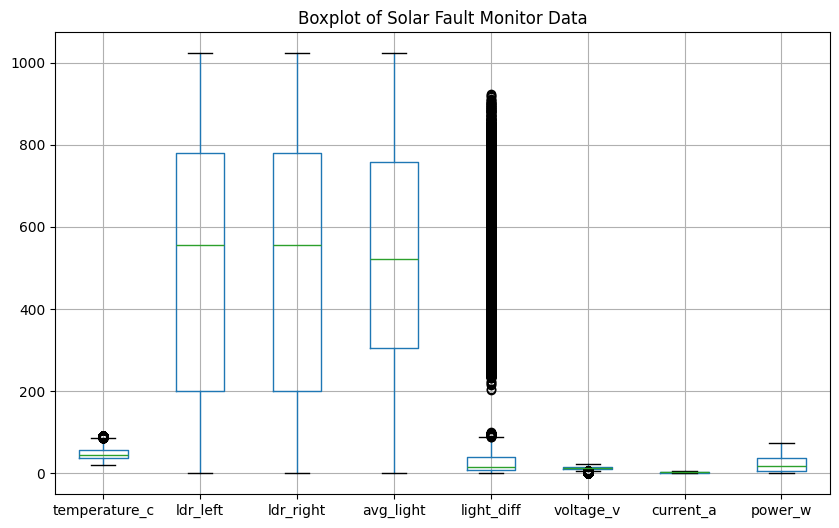

In [8]:
plt.figure(figsize=(10, 6))
df.boxplot()
plt.title('Boxplot of Solar Fault Monitor Data')
plt.show()

## **Data Cleaning**

In [9]:
df.rename(columns={'label': 'fault_type'}, inplace=True)

In [10]:
LABEL_MAP = {
    'NORMAL': 0, 'LOW_LIGHT': 1, 'SHADOW': 2,
    'OVERHEAT': 3, 'PANEL_FAULT': 4
}

df['fault_type'] = df['fault_type'].map(LABEL_MAP)
df.head(10)

,temperature_c,ldr_left,ldr_right,avg_light,light_diff,voltage_v,current_a,power_w,fault_type,split
0,67.50,836.58,834.56,835.57,2.02,14.2718,3.1061,44.3302,3,train
1,40.27,484.73,489.19,486.96,4.46,15.4586,1.2000,18.5503,0,train
2,50.66,834.49,829.72,832.10,4.77,16.1058,3.3123,53.3475,0,train
3,31.45,233.34,240.18,236.76,6.84,14.4954,0.0475,0.6889,1,train
4,78.53,748.68,730.03,739.36,18.65,13.1240,2.2516,29.5496,3,train
5,45.83,626.64,614.25,620.44,12.39,3.2434,4.2303,13.7205,4,train
6,38.00,119.80,120.31,120.06,0.51,11.7337,0.2901,3.4045,1,test
7,39.56,435.74,468.49,452.12,32.75,19.0356,0.0401,0.7629,4,train
8,51.57,775.47,748.87,762.17,26.60,14.7097,2.9988,44.1120,0,validation
9,76.49,912.12,926.91,919.52,14.79,13.3385,3.2757,43.6933,3,train


In [19]:
df.to_csv('../data/solar_fault_monitor_preprocessed.csv', index=False)